# 23 · Boundary mechanism: network, destinations, and population

Single Colab experiment, no manuscript edits. Reproduces the Gate 13 district/regional FPT gaps, then splits each regional–district contrast into three **exactly additive** differences: (1) network with city targets and city residents; (2) replacing city targets with regional targets while keeping city residents; (3) adding regional residents. Uses one paired Poisson(1) household bootstrap with 500 replicates and max-$t$ intervals across employment, education, and health. The three components are ordered contrasts, not causal effects; changing the order changes the allocation.

Requires the validated Gate 4/6/11/12 files in Drive and the two previously uploaded official survey ZIPs. Writes results to `MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate24/`. Rerun safely: completed bootstrap replicates are checkpointed every 25 draws. No new downloads from the Observatory.


In [1]:
%pip -q install pandas pyarrow numpy scipy matplotlib seaborn geopandas networkx


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import csv, hashlib, json, os, re, shutil, unicodedata, zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate24"
OUT = ROOT / "outputs/bogota_em2023/gate24"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (RAW, INTERIM): directory.mkdir(parents=True, exist_ok=True)

SOURCE_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/05_Base%20datos%20procesada%20EODH.zip"
ZONING_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/03_Zonificacion%20EODH%20%281%29.zip"
PURPOSES = ("employment", "education", "health")
EFFECTS = ("female_minus_male_total", "residential_contribution", "kernel_contribution")
TAU = 20.0
BOOTSTRAP_REPLICATES = 500
RANDOM_SEED = 202324

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

OUT = Path(os.environ.get("GATE24_DIR_OVERRIDE", DRIVE_BASE / "results/gate24"))
OUT.mkdir(parents=True, exist_ok=True)
G4 = Path(os.environ.get("GATE4_DIR_OVERRIDE", DRIVE_BASE / "results/gate4"))
G6 = Path(os.environ.get("GATE6_DIR_OVERRIDE", DRIVE_BASE / "results/gate6"))
G11 = Path(os.environ.get("GATE11_DIR_OVERRIDE", DRIVE_BASE / "results/gate11"))
G12 = Path(os.environ.get("GATE12_DIR_OVERRIDE", DRIVE_BASE / "results/gate12"))
paths = {
    "region_edges": G4 / "transition_edges_utam.parquet",
    "region_targets": G6 / "purpose_target_sets.csv",
    "region_point": G11 / "final_female_male_point_estimates.csv",
    "city_targets": G12 / "bogota_dc_internal_core50_targets.csv",
    "city_point": G12 / "bogota_dc_internal_female_male_point_estimates.csv",
    "gate11": G11 / "gate_11.json", "gate12": G12 / "gate_12.json",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing: raise FileNotFoundError("Faltan insumos validados: " + ", ".join(missing))
gate11 = json.loads(paths["gate11"].read_text(encoding="utf-8"))
gate12 = json.loads(paths["gate12"].read_text(encoding="utf-8"))
if not gate11.get("gate", {}).get("gate_11_passed", False): raise RuntimeError("Gate 11 no aprobada")
if not gate12.get("gate", {}).get("gate_12_passed", False): raise RuntimeError("Gate 12 no aprobada")
print("Réplicas pareadas:", BOOTSTRAP_REPLICATES)
print("Salida:", OUT)


Mounted at /content/drive
Réplicas pareadas: 500
Salida: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate24


In [3]:
def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)

def ensure_archive(runtime_name, drive_name, url, label):
    runtime, cached = RAW / runtime_name, DRIVE_BASE / drive_name
    if valid_zip(runtime): return runtime, "runtime_cache"
    if valid_zip(cached):
        shutil.copy2(cached, runtime); return runtime, "google_drive_cache"
    from google.colab import files
    print(f"Descargue y seleccione el ZIP de {label}:\n{url}")
    uploaded = files.upload()
    if len(uploaded) != 1: raise ValueError("Suba exactamente un ZIP")
    name, content = next(iter(uploaded.items()))
    temporary = runtime.with_suffix(".zip.upload"); temporary.write_bytes(content); del content
    if not valid_zip(temporary): temporary.unlink(missing_ok=True); raise ValueError(f"{name} no es ZIP válido")
    temporary.replace(runtime); DRIVE_BASE.mkdir(parents=True, exist_ok=True); shutil.copy2(runtime, cached)
    return runtime, "manual_upload"

def safe_extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True); queue = [(Path(zip_path), destination)]; visited = set()
    while queue:
        current, target = queue.pop(0); signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited: continue
        visited.add(signature); root = target.resolve()
        with zipfile.ZipFile(current) as zipped:
            for member in zipped.infolist():
                resolved = (target / member.filename).resolve()
                if root != resolved and root not in resolved.parents: raise ValueError(f"Ruta insegura: {member.filename}")
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            if (str(nested.resolve()), str(nested_target.resolve())) not in visited: queue.append((nested, nested_target))

survey_archive, survey_method = ensure_archive("processed_edoh.zip", "processed_edoh.zip", SOURCE_URL, "microdatos")
zoning_archive, zoning_method = ensure_archive("zoning_edoh.zip", "zoning_edoh.zip", ZONING_URL, "zonificación")
safe_extract_recursive(survey_archive, INTERIM / "processed_edoh")
safe_extract_recursive(zoning_archive, INTERIM / "zoning_edoh")
print("Microdatos:", survey_method, "| Zonificación:", zoning_method)


Microdatos: google_drive_cache | Zonificación: google_drive_cache


In [4]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(c for c in value if not unicodedata.combining(c))
    return re.sub(r"[^a-z0-9]+", "_", value.lower().strip()).strip("_")

def clean_key(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    return cleaned.mask(cleaned.map(normalize).isin(["", "nan", "none", "na", "no_aplica", "sin_informacion"]))

def canonical_utam(series):
    cleaned = clean_key(series)
    def one(value):
        if pd.isna(value): return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        match = re.fullmatch(r"UPR0*(\d+)", text)
        if match: return f"UPR{int(match.group(1)):04d}"
        match = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        return f"UTAM{int(match.group(1)):03d}" if match else text
    return cleaned.map(one).astype("string")

def parse_number(series):
    raw = series.astype("string").str.strip()
    if float(raw.str.contains(",", regex=False, na=False).mean()) > 0.05:
        raw = raw.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")

def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle: sample = handle.read(32768)
            return encoding, csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except (UnicodeDecodeError, csv.Error): pass
    raise ValueError(f"Formato no detectado: {path}")

def find_module(token, excluded=()):
    candidates = [p for p in (INTERIM / "processed_edoh").rglob("*.csv")
                  if token in normalize(p.stem) and not any(x in normalize(p.stem) for x in excluded)]
    if not candidates: raise FileNotFoundError(token)
    return sorted(candidates, key=lambda p: (len(p.parts), len(p.name)))[0]

def read_selected(path, required):
    encoding, delimiter = csv_format(path)
    header = pd.read_csv(path, sep=delimiter, encoding=encoding, nrows=0)
    mapping = {normalize(c): c for c in header.columns}; absent = sorted(set(required) - set(mapping))
    if absent: raise KeyError(f"Faltan columnas {absent}")
    frame = pd.read_csv(path, sep=delimiter, encoding=encoding,
                        usecols=[mapping[c] for c in required], dtype="string", low_memory=False)
    frame.columns = [normalize(c) for c in frame.columns]; return frame

trips = read_selected(find_module("viaje", excluded=("etapa",)),
                      ["key_hg", "utam_ori", "utam_des", "fexp_vj", "sexo"])
persons = read_selected(find_module("persona"),
                        ["key_hg", "cod_utam_hg", "fexp_per_5anos", "sexo"])
trips["household"] = clean_key(trips["key_hg"]); trips["utam_ori"] = canonical_utam(trips["utam_ori"])
trips["utam_des"] = canonical_utam(trips["utam_des"]); trips["weight"] = parse_number(trips["fexp_vj"])
trips["sex_group"] = trips["sexo"].map(normalize)
persons["household"] = clean_key(persons["key_hg"]); persons["residence_utam"] = canonical_utam(persons["cod_utam_hg"])
persons["weight"] = parse_number(persons["fexp_per_5anos"]); persons["sex_group"] = persons["sexo"].map(normalize)
trips = trips[trips[["household", "utam_ori", "utam_des"]].notna().all(axis=1) & trips["weight"].gt(0)].reset_index(drop=True)
persons = persons[persons[["household", "residence_utam"]].notna().all(axis=1) & persons["weight"].gt(0)].reset_index(drop=True)

spatial_paths = list((INTERIM / "zoning_edoh").rglob("*.shp")) + list((INTERIM / "zoning_edoh").rglob("*.gpkg"))
candidates = []
for path in spatial_paths:
    try:
        cols = {normalize(c): c for c in gpd.read_file(path, rows=5).columns}
        if "utam" in cols: candidates.append(path)
    except Exception: pass
if not candidates: raise FileNotFoundError("Capa UTAM")
utam_path = sorted(candidates, key=lambda p: ("utam2023" not in normalize(p.stem), len(p.parts)))[0]
layer = gpd.read_file(utam_path); cmap = {normalize(c): c for c in layer.columns}
mun_key = "munnombre" if "munnombre" in cmap else next(k for k in cmap if "mun" in k and "nombre" in k)
lookup = pd.DataFrame({"utam": canonical_utam(layer[cmap["utam"]]), "municipality": layer[cmap[mun_key]].map(normalize)}).dropna()
city_all_nodes = set(lookup.loc[lookup["municipality"].str.contains("bogota", na=False), "utam"])
print("Viajes:", len(trips), "| Personas:", len(persons), "| UTAM Bogotá:", len(city_all_nodes))


Viajes: 97796 | Personas: 64989 | UTAM Bogotá: 116


In [5]:
all_households = pd.Index(sorted(set(trips["household"].astype(str)) | set(persons["household"].astype(str))))
household_to_code = {h: i for i, h in enumerate(all_households)}

def build_scope(name, scope_trips, scope_persons, nodes, P0, target_path):
    nodes = sorted(nodes); node_to_index = {node: i for i, node in enumerate(nodes)}; n = len(nodes)
    scope_trips = scope_trips[scope_trips["utam_ori"].isin(nodes) & scope_trips["utam_des"].isin(nodes)].reset_index(drop=True)
    scope_persons = scope_persons[scope_persons["residence_utam"].isin(nodes)].reset_index(drop=True)
    target_table = pd.read_csv(target_path, dtype={"utam": "string"})
    target_table["utam"] = canonical_utam(target_table["utam"])
    targets = {}
    for purpose in PURPOSES:
        mask = target_table["purpose_group"].eq(purpose)
        if "target_definition" in target_table: mask &= target_table["target_definition"].eq("core_50")
        codes = set(target_table.loc[mask, "utam"])
        missing = codes - set(nodes)
        if not codes or missing: raise RuntimeError(f"Objetivos inválidos {name}/{purpose}: {missing}")
        targets[purpose] = np.array(sorted(node_to_index[x] for x in codes), dtype=int)
    return {
        "name": name, "nodes": nodes, "n": n, "P0": P0, "targets": targets,
        "trips": scope_trips, "persons": scope_persons,
        "origin": scope_trips["utam_ori"].map(node_to_index).to_numpy(dtype=int),
        "destination": scope_trips["utam_des"].map(node_to_index).to_numpy(dtype=int),
        "trip_weight": scope_trips["weight"].to_numpy(dtype=float),
        "residence": scope_persons["residence_utam"].map(node_to_index).to_numpy(dtype=int),
        "person_weight": scope_persons["weight"].to_numpy(dtype=float),
        "trip_hh": scope_trips["household"].astype(str).map(household_to_code).to_numpy(dtype=int),
        "person_hh": scope_persons["household"].astype(str).map(household_to_code).to_numpy(dtype=int),
        "trip_masks": {g: scope_trips["sex_group"].eq(g).fillna(False).to_numpy(dtype=bool) for g in ("mujer", "hombre")},
        "person_masks": {g: scope_persons["sex_group"].eq(g).fillna(False).to_numpy(dtype=bool) for g in ("mujer", "hombre")},
    }

edges = pd.read_parquet(paths["region_edges"]); edges["utam_ori"] = canonical_utam(edges["utam_ori"]); edges["utam_des"] = canonical_utam(edges["utam_des"])
region_nodes = sorted(set(edges["utam_ori"]) | set(edges["utam_des"])); rmap = {node: i for i, node in enumerate(region_nodes)}
region_P0 = np.zeros((len(region_nodes), len(region_nodes)))
for row in edges.itertuples(index=False): region_P0[rmap[row.utam_ori], rmap[row.utam_des]] = float(row.transition_probability)

city_trips0 = trips[trips["utam_ori"].isin(city_all_nodes) & trips["utam_des"].isin(city_all_nodes)].copy()
graph = nx.DiGraph(); grouped = city_trips0.groupby(["utam_ori", "utam_des"], observed=True)["weight"].sum()
graph.add_weighted_edges_from((o, d, float(w)) for (o, d), w in grouped.items())
city_nodes = sorted(max(nx.strongly_connected_components(graph), key=len)); cmap2 = {node: i for i, node in enumerate(city_nodes)}
city_trips0 = city_trips0[city_trips0["utam_ori"].isin(city_nodes) & city_trips0["utam_des"].isin(city_nodes)].copy()
W = np.zeros((len(city_nodes), len(city_nodes)))
np.add.at(W, (city_trips0["utam_ori"].map(cmap2).to_numpy(dtype=int), city_trips0["utam_des"].map(cmap2).to_numpy(dtype=int)), city_trips0["weight"].to_numpy(dtype=float))
city_P0 = W / W.sum(axis=1)[:, None]

scopes = {
    "bogota_region": build_scope("bogota_region", trips, persons, region_nodes, region_P0, paths["region_targets"]),
    "bogota_dc_internal": build_scope("bogota_dc_internal", city_trips0, persons, city_nodes, city_P0, paths["city_targets"]),
}
display(pd.DataFrame([{ "scope": name, "nodes": s["n"], "trips": len(s["trips"]), "persons": len(s["persons"])} for name, s in scopes.items()]))


,scope,nodes,trips,persons
0,bogota_region,141,97796,64373
1,bogota_dc_internal,114,76168,48373


## Estimands and point-estimate checks

Let $G_D$ be the district gap using district targets and residents; $G_{R,C}$ the regional-kernel gap for residents of the **validated district SCC**, with district targets; $G_{R,T}$ the same regional kernel and residents with regional targets; and $G_R$ the regional gap with all residents and regional targets. Then $G_R-G_D=(G_{R,C}-G_D)+(G_{R,T}-G_{R,C})+(G_R-G_{R,T})$. The first term fixes destination nodes and starting population, but the model still changes how those destinations can be reached through the extended network. The city-resident restriction uses the same city SCC support as Gate 13 and renormalizes each sex's starting distribution outside the relevant target set.


In [6]:
def regularized_kernel(s, level, global_multiplier=None):
    mask = s["trip_masks"][level]; selected = np.flatnonzero(mask); original = s["trip_weight"][selected]
    multiplicity = np.ones(len(selected)) if global_multiplier is None else global_multiplier[s["trip_hh"][selected]].astype(float)
    weights, squared = original * multiplicity, original ** 2 * multiplicity
    origins, destinations = s["origin"][selected], s["destination"][selected]; positive = weights > 0
    W = np.zeros((s["n"], s["n"])); np.add.at(W, (origins[positive], destinations[positive]), weights[positive])
    out = W.sum(axis=1); sum_sq = np.bincount(origins[positive], weights=squared[positive], minlength=s["n"])
    ess = np.divide(out ** 2, sum_sq, out=np.zeros(s["n"]), where=sum_sq > 0)
    empirical = np.zeros_like(W); observed = out > 0; empirical[observed] = W[observed] / out[observed, None]
    omega = ess / (ess + TAU); return omega[:, None] * empirical + (1 - omega[:, None]) * s["P0"]

def residential_distribution(s, level, global_multiplier=None):
    mask = s["person_masks"][level]; selected = np.flatnonzero(mask)
    multiplicity = np.ones(len(selected)) if global_multiplier is None else global_multiplier[s["person_hh"][selected]].astype(float)
    mu = np.bincount(s["residence"][selected], weights=s["person_weight"][selected] * multiplicity, minlength=s["n"]).astype(float)
    if not np.isfinite(mu).all() or mu.sum() <= 0: raise RuntimeError("Distribución residencial vacía")
    return mu / mu.sum()

def first_passage(s, P, targets):
    target_mask = np.zeros(s["n"], dtype=bool); target_mask[targets] = True; transient = np.flatnonzero(~target_mask)
    h = np.zeros(s["n"]); h[transient] = np.linalg.solve(np.eye(len(transient)) - P[np.ix_(transient, transient)], np.ones(len(transient)))
    return h

def condition(mu, targets):
    result = mu.copy(); result[targets] = 0
    if result.sum() <= 0: raise RuntimeError("Masa fuera del objetivo vacía")
    return result / result.sum()

def gap_values(h_w, h_m, mu_w, mu_m, targets):
    mu_w, mu_m = condition(mu_w, targets), condition(mu_m, targets)
    mm, mw, wm, ww = float(mu_m @ h_m), float(mu_w @ h_m), float(mu_m @ h_w), float(mu_w @ h_w)
    residence = .5 * ((mw - mm) + (ww - wm)); kernel = .5 * ((wm - mm) + (ww - mw)); total = ww - mm
    return {"female_minus_male_total": total, "residential_contribution": residence,
            "kernel_contribution": kernel, "closure_error": total - residence - kernel}

def evaluate_scope(s, multiplier=None):
    kernels = {g: regularized_kernel(s, g, multiplier) for g in ("mujer", "hombre")}
    mus = {g: residential_distribution(s, g, multiplier) for g in ("mujer", "hombre")}
    result = {}
    for purpose in PURPOSES:
        targets = s["targets"][purpose]
        result[purpose] = gap_values(first_passage(s, kernels["mujer"], targets),
                                     first_passage(s, kernels["hombre"], targets),
                                     mus["mujer"], mus["hombre"], targets)
    return result



In [7]:
CITY_NODE_SET = set(scopes["bogota_dc_internal"]["nodes"])
region = scopes["bogota_region"]
city = scopes["bogota_dc_internal"]
region["city_resident_mask"] = region["persons"]["residence_utam"].isin(CITY_NODE_SET).fillna(False).to_numpy(bool)
assert set(city["nodes"]).issubset(set(region["nodes"]))
assert all(set(city["nodes"][i] for i in city["targets"][p]).issubset(set(region["nodes"])) for p in PURPOSES)
city_targets_region = {
    p: np.array(sorted(region["nodes"].index(city["nodes"][j]) for j in city["targets"][p]), dtype=int)
    for p in PURPOSES
}
assert all(len(city_targets_region[p]) == len(city["targets"][p]) for p in PURPOSES)

def region_city_mu(group, multiplier=None):
    selected = np.flatnonzero(region["person_masks"][group] & region["city_resident_mask"])
    weights = region["person_weight"][selected].copy()
    if multiplier is not None:
        weights *= multiplier[region["person_hh"][selected]]
    mu = np.bincount(region["residence"][selected], weights=weights, minlength=region["n"]).astype(float)
    if mu.sum() <= 0: raise RuntimeError("No city-resident mass for " + group)
    return mu / mu.sum()

def evaluate_four(multiplier=None):
    # Reuse each sex-specific kernel and starting mass across all target choices.
    kd = {g: regularized_kernel(city, g, multiplier) for g in ("mujer", "hombre")}
    kr = {g: regularized_kernel(region, g, multiplier) for g in ("mujer", "hombre")}
    md = {g: residential_distribution(city, g, multiplier) for g in ("mujer", "hombre")}
    mr = {g: residential_distribution(region, g, multiplier) for g in ("mujer", "hombre")}
    mc = {g: region_city_mu(g, multiplier) for g in ("mujer", "hombre")}
    result = {}
    for purpose in PURPOSES:
        td, tr, tc = city["targets"][purpose], region["targets"][purpose], city_targets_region[purpose]
        hd = {g: first_passage(city, kd[g], td) for g in kd}
        hc = {g: first_passage(region, kr[g], tc) for g in kr}
        hr = {g: first_passage(region, kr[g], tr) for g in kr}
        states = {
            "district": gap_values(hd["mujer"], hd["hombre"], md["mujer"], md["hombre"], td),
            "regional_city_targets_city_residents": gap_values(hc["mujer"], hc["hombre"], mc["mujer"], mc["hombre"], tc),
            "regional_targets_city_residents": gap_values(hr["mujer"], hr["hombre"], mc["mujer"], mc["hombre"], tr),
            "regional_all": gap_values(hr["mujer"], hr["hombre"], mr["mujer"], mr["hombre"], tr),
        }
        d, c, t, a = [states[k]["female_minus_male_total"] for k in states]
        terms = {"network_fixed_targets_residents": c-d, "target_set_change": t-c,
                 "added_residents": a-t, "total_region_minus_district": a-d}
        terms["identity_error"] = sum(terms[x] for x in ("network_fixed_targets_residents","target_set_change","added_residents")) - terms["total_region_minus_district"]
        result[purpose] = {"states": states, "terms": terms}
    return result

point = evaluate_four()
point_rows = [{"purpose_group": p, **point[p]["terms"], **{
    "gap_" + name: state["female_minus_male_total"]
    for name, state in point[p]["states"].items()
}} for p in PURPOSES]
point_frame = pd.DataFrame(point_rows)
validated = {
    "district": pd.read_csv(paths["city_point"]).set_index("purpose_group"),
    "regional_all": pd.read_csv(paths["region_point"]).set_index("purpose_group"),
}
for p in PURPOSES:
    for name in validated:
        old = float(validated[name].loc[p, "female_minus_male_total"])
        new = float(point[p]["states"][name]["female_minus_male_total"])
        assert abs(old-new) < 1e-8, (p, name, old, new)
    assert abs(point[p]["terms"]["identity_error"]) < 1e-10
assert np.isfinite(point_frame.select_dtypes(include="number").to_numpy()).all()
point_frame.to_csv(OUT / "boundary_mechanism_point.csv", index=False)
display(point_frame.round(4))
print("Gate 11/12 reference estimates reproduced; exact telescoping identity closed.")

,purpose_group,network_fixed_targets_residents,target_set_change,added_residents,total_region_minus_district,identity_error,gap_district,gap_regional_city_targets_city_residents,gap_regional_targets_city_residents,gap_regional_all
0,employment,0.0153,0.0023,0.5021,0.5197,0.0,0.4790,0.4943,0.4966,0.9987
1,education,0.0523,-0.0563,0.4327,0.4287,0.0,0.3986,0.4509,0.3947,0.8274
2,health,-0.0273,0.0009,0.4913,0.4649,0.0,0.2405,0.2132,0.2140,0.7054


Gate 11/12 reference estimates reproduced; exact telescoping identity closed.


## Paired household bootstrap and reproducible outputs

Every replicate uses the **same Poisson(1) household multipliers** in all four states; the population reference kernels, strongly connected components, and frozen target sets remain fixed, as in Gate 13. This estimates sampling uncertainty conditional on the selected targets and network components. Intervals are max-$t$ simultaneous over the three purposes *separately for each term*; they are not jointly simultaneous across the three terms. Deterministic per-replicate seeds permit safe restart after a Colab disconnect. This new run does not overwrite the original Gate 13 inferential results.

In [8]:
from IPython.display import display
TERMS = ("network_fixed_targets_residents", "target_set_change", "added_residents", "total_region_minus_district")
CONFIG = {
    "seed": RANDOM_SEED, "replicates": BOOTSTRAP_REPLICATES, "tau": TAU,
    "purposes": PURPOSES, "city_nodes": sorted(city["nodes"]), "region_nodes": sorted(region["nodes"]),
    "city_targets": {p: [city["nodes"][j] for j in city["targets"][p]] for p in PURPOSES},
    "region_targets": {p: [region["nodes"][j] for j in region["targets"][p]] for p in PURPOSES},
}
for key in ("region_edges", "region_targets", "city_targets", "gate11", "gate12"):
    with open(paths[key], "rb") as handle:
        CONFIG["sha256_" + key] = hashlib.file_digest(handle, "sha256").hexdigest()
CONFIG_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True, default=str).encode()).hexdigest()
checkpoint = OUT / "boundary_mechanism_bootstrap.parquet"
manifest = OUT / "boundary_mechanism_manifest.json"
if checkpoint.exists() != manifest.exists():
    raise RuntimeError("Incomplete bootstrap checkpoint: inspect results/gate24 before rerunning")
if manifest.exists():
    previous = json.loads(manifest.read_text(encoding="utf-8"))
    if previous["config_hash"] != CONFIG_HASH:
        raise RuntimeError("Inputs or configuration changed: use a new output directory to prevent mixed bootstrap runs")
    completed = pd.read_parquet(checkpoint)
else:
    completed = pd.DataFrame(columns=["replicate","purpose_group",*TERMS,"identity_error"])
done = sorted(completed["replicate"].dropna().astype(int).unique())
assert done == list(range(1, len(done)+1)), "Checkpoint missing an intermediate replicate"
assert len(completed) == len(done) * len(PURPOSES), "Checkpoint has incomplete replicate"
for replicate in range(len(done)+1, BOOTSTRAP_REPLICATES+1):
    rng = np.random.default_rng(np.random.SeedSequence([RANDOM_SEED, replicate]))
    mult = rng.poisson(1, len(all_households))
    result = evaluate_four(mult)
    rows = [{"replicate": replicate, "purpose_group": p, **result[p]["terms"]} for p in PURPOSES]
    completed = pd.concat([completed, pd.DataFrame(rows)], ignore_index=True)
    if replicate % 25 == 0 or replicate == BOOTSTRAP_REPLICATES:
        temporary = checkpoint.with_suffix(".tmp.parquet")
        completed.to_parquet(temporary, index=False)
        os.replace(temporary, checkpoint)
        manifest.write_text(json.dumps({"config_hash": CONFIG_HASH, "configuration": CONFIG,
                                        "completed_replicates": replicate}, ensure_ascii=False, indent=2),
                            encoding="utf-8")
        print(f"Gate 24: {replicate}/{BOOTSTRAP_REPLICATES} replicates saved on Drive")
assert len(completed) == BOOTSTRAP_REPLICATES*len(PURPOSES)
assert completed.groupby("purpose_group")["replicate"].nunique().eq(BOOTSTRAP_REPLICATES).all()
assert np.isfinite(completed[list(TERMS)+["identity_error"]].to_numpy(float)).all()
assert completed["identity_error"].abs().max() < 1e-9
print("Complete: paired replicates and exact additivity verified.")

/tmp/ipykernel_4665/1113364961.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  completed = pd.concat([completed, pd.DataFrame(rows)], ignore_index=True)


Gate 24: 25/500 replicates saved on Drive
Gate 24: 50/500 replicates saved on Drive
Gate 24: 75/500 replicates saved on Drive
Gate 24: 100/500 replicates saved on Drive
Gate 24: 125/500 replicates saved on Drive
Gate 24: 150/500 replicates saved on Drive
Gate 24: 175/500 replicates saved on Drive
Gate 24: 200/500 replicates saved on Drive
Gate 24: 225/500 replicates saved on Drive
Gate 24: 250/500 replicates saved on Drive
Gate 24: 275/500 replicates saved on Drive
Gate 24: 300/500 replicates saved on Drive
Gate 24: 325/500 replicates saved on Drive
Gate 24: 350/500 replicates saved on Drive
Gate 24: 375/500 replicates saved on Drive
Gate 24: 400/500 replicates saved on Drive
Gate 24: 425/500 replicates saved on Drive
Gate 24: 450/500 replicates saved on Drive
Gate 24: 475/500 replicates saved on Drive
Gate 24: 500/500 replicates saved on Drive
Complete: paired replicates and exact additivity verified.


,purpose_group,term,point_estimate,bootstrap_sd,percentile_ci_lower,percentile_ci_upper,max_t_critical,simultaneous_ci_lower,simultaneous_ci_upper,interval_family,simultaneously_positive
0,employment,network_fixed_targets_residents,0.0153,0.0295,-0.0420,0.0704,2.2450,-0.0510,0.0816,three_purposes_per_term,False
1,education,network_fixed_targets_residents,0.0523,0.0372,-0.0188,0.1229,2.2450,-0.0311,0.1357,three_purposes_per_term,False
2,health,network_fixed_targets_residents,-0.0273,0.0409,-0.1022,0.0547,2.2450,-0.1192,0.0646,three_purposes_per_term,False
3,employment,target_set_change,0.0023,0.0447,-0.0871,0.0850,2.3224,-0.1015,0.1061,three_purposes_per_term,False
4,education,target_set_change,-0.0563,0.0599,-0.1753,0.0639,2.3224,-0.1953,0.0828,three_purposes_per_term,False
5,health,target_set_change,0.0009,0.0471,-0.0976,0.0869,2.3224,-0.1086,0.1104,three_purposes_per_term,False
6,employment,added_residents,0.5021,0.1454,0.2933,0.8603,2.3774,0.1563,0.8479,three_purposes_per_term,True
7,education,added_residents,0.4327,0.1441,0.2388,0.7869,2.3774,0.0902,0.7753,three_purposes_per_term,True
8,health,added_residents,0.4913,0.1488,0.2765,0.8342,2.3774,0.1375,0.8452,three_purposes_per_term,True
9,employment,total_region_minus_district,0.5197,0.1578,0.2754,0.9026,2.4377,0.1351,0.9043,three_purposes_per_term,True


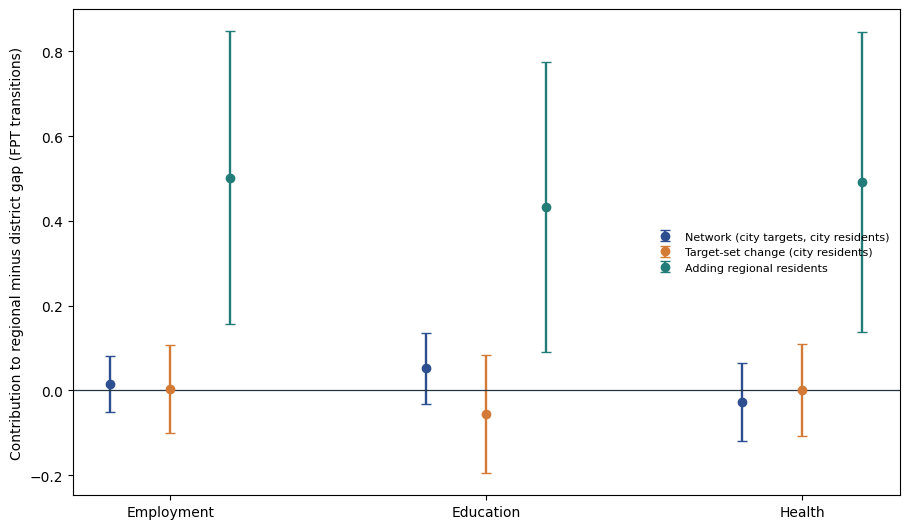

Gate 24 PASSED. Review point estimates, intervals and graph before changing manuscript claims.
Results directory: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate24


In [9]:
records = []
point_index = point_frame.set_index("purpose_group")
for term in TERMS:
    wide = completed.pivot(index="replicate", columns="purpose_group", values=term).reindex(columns=PURPOSES)
    wide = wide.astype(float)
    centre = point_index[term].reindex(PURPOSES).astype(float)
    sd = wide.std(axis=0, ddof=1)
    assert sd.gt(0).all(), (term, sd.to_dict())
    maxima = wide.subtract(centre, axis=1).abs().divide(sd, axis=1).max(axis=1)
    critical = float(maxima.quantile(.95))
    for purpose in PURPOSES:
        value, sigma = float(centre[purpose]), float(sd[purpose])
        sample = wide[purpose]
        records.append({
            "purpose_group": purpose, "term": term, "point_estimate": value,
            "bootstrap_sd": sigma, "percentile_ci_lower": float(sample.quantile(.025)),
            "percentile_ci_upper": float(sample.quantile(.975)),
            "max_t_critical": critical, "simultaneous_ci_lower": value-critical*sigma,
            "simultaneous_ci_upper": value+critical*sigma, "interval_family": "three_purposes_per_term",
            "simultaneously_positive": bool(value-critical*sigma > 0),
        })
intervals = pd.DataFrame(records)
intervals.to_csv(OUT / "boundary_mechanism_intervals.csv", index=False)
display(intervals.round(4))

# Validity gates check reconstruction, algebra, bootstrap completeness and numerical finiteness.
checks = {
    "original_district_and_region_point_values_reproduced": True,
    "city_SCC_residents_present_in_region": bool(region["city_resident_mask"].sum() > 0),
    "three_term_point_identity": bool(point_frame["identity_error"].abs().max() < 1e-10),
    "three_term_bootstrap_identity": bool(completed["identity_error"].abs().max() < 1e-9),
    "complete_shared_household_bootstrap": bool(len(completed) == BOOTSTRAP_REPLICATES*len(PURPOSES)),
    "all_intervals_finite": bool(np.isfinite(intervals[["point_estimate","simultaneous_ci_lower","simultaneous_ci_upper"]].to_numpy(float)).all()),
}
gate = {"gate_24_passed": bool(all(checks.values())), "checks": checks,
        "config_hash": CONFIG_HASH, "replicates": BOOTSTRAP_REPLICATES,
        "estimand": "ordered three-term descriptive decomposition of regional minus district FPT gap",
        "uncertainty": "per-term max-t 95% simultaneous over three purposes; SCC, P0 and targets fixed"}
(OUT / "gate_24.json").write_text(json.dumps(gate, ensure_ascii=False, indent=2), encoding="utf-8")
if not gate["gate_24_passed"]: raise RuntimeError("Gate 24 failed: " + str(checks))

fig, ax = plt.subplots(figsize=(9.2, 5.4))
colors = {"network_fixed_targets_residents":"#2D4E8F","target_set_change":"#D47A37",
          "added_residents":"#227C78"}
names = {"network_fixed_targets_residents":"Network (city targets, city residents)",
         "target_set_change":"Target-set change (city residents)",
         "added_residents":"Adding regional residents"}
for j, term in enumerate(colors):
    part = intervals[intervals.term.eq(term)].set_index("purpose_group").reindex(PURPOSES)
    x = np.arange(len(PURPOSES)) + (j-1)*.19
    yy = part.point_estimate.to_numpy(float)
    ax.errorbar(x, yy, yerr=[yy-part.simultaneous_ci_lower.to_numpy(float),
               part.simultaneous_ci_upper.to_numpy(float)-yy], fmt="o", capsize=3.5,
               color=colors[term], label=names[term], linewidth=1.7)
ax.axhline(0, color="#233642", lw=.9)
ax.set_xticks(np.arange(len(PURPOSES)), [p.title() for p in PURPOSES])
ax.set_ylabel("Contribution to regional minus district gap (FPT transitions)")
ax.legend(frameon=False, fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(OUT / "figure_boundary_mechanism.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "figure_boundary_mechanism.pdf", bbox_inches="tight")
plt.show()
print("Gate 24 PASSED. Review point estimates, intervals and graph before changing manuscript claims.")
print("Results directory:", OUT)